<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/TTM/TTM_Bullish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## TTM Squeeze Analysis

This code performs a comprehensive parameter sweep for a TTM Squeeze trading strategy across multiple symbols and configurations. It will identify optimal strategy configurations based on forward returns and win rates.

In [25]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

### TTM Squeeze Configuration and Analysis

In [26]:
# --- 1. Configuration & Symbol Loading ---
# TTM Squeeze Configuration Parameters
BB_LENGTHS = [20, 25, 30]  # Bollinger Band lengths
KC_LENGTHS = [20, 25, 30]  # Keltner Channel lengths
KC_DEVS = [1.5, 2.0, 2.5]   # Keltner Channel deviation multiples
BB_DEVS = 2.0 # Standard Bollinger Band deviation

# Load Symbols from your OptionVolume
try:
    df_csv = pd.read_csv(OptionVolume)
    # Ensuring we handle different possible column names for Symbol
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT"]

# --- 2. TTM Squeeze Function ---
def calculate_ttm_squeeze(df, bb_len, bb_dev, kc_len, kc_dev):
    # Bollinger Bands
    df['SMA'] = df['Close'].rolling(window=bb_len).mean()
    df['StdDev'] = df['Close'].rolling(window=bb_len).std()
    df['BB_Upper'] = df['SMA'] + (df['StdDev'] * bb_dev)
    df['BB_Lower'] = df['SMA'] - (df['StdDev'] * bb_dev)

    # Keltner Channels
    df['TR'] = np.maximum(df['High'] - df['Low'],
                          np.maximum(abs(df['High'] - df['Close'].shift()),
                                     abs(df['Low'] - df['Close'].shift())))
    df['ATR'] = df['TR'].rolling(window=kc_len).mean()
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['KC_Middle'] = df['Typical_Price'].rolling(window=kc_len).mean()
    df['KC_Upper'] = df['KC_Middle'] + (df['ATR'] * kc_dev)
    df['KC_Lower'] = df['KC_Middle'] - (df['ATR'] * kc_dev)

    # TTM Squeeze Condition: Squeeze is "on" when BB are inside KC
    df['in_squeeze'] = (df['BB_Lower'] > df['KC_Lower']) & \
                       (df['BB_Upper'] < df['KC_Upper'])

    # Momentum Oscillator (similar to ThinkorSwim's TTM Squeeze histogram)
    # Value1 = Typical Price
    # Value2 = SMA(Value1, 20)
    # Momentum_Raw = Value1 - Value2
    # Momentum_Smoothed = SMA(Momentum_Raw, 4)
    df['Momentum_Value1'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['Momentum_Value2'] = df['Momentum_Value1'].rolling(window=20).mean()
    df['Momentum_Raw'] = df['Momentum_Value1'] - df['Momentum_Value2']
    df['Momentum_Smoothed'] = df['Momentum_Raw'].rolling(window=4).mean()
    df['is_positive_momentum'] = df['Momentum_Smoothed'] > 0

    return df

# --- 3. Data Fetching & Vectorized Math ---
print("Fetching data and calculating vectorized returns...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, period="5y", interval="1d", progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # VECTORIZED RETURN CALCULATION
        # Calculate percentage change and shift it backward to see future results
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep ---
all_results = []

for bb_len in BB_LENGTHS:
    for kc_len in KC_LENGTHS:
        for kc_dev in KC_DEVS:
            param_trades = []

            print(f"Processing BB_Len={bb_len}, KC_Len={kc_len}, KC_Dev={kc_dev}")

            for symbol, df_orig in data_cache.items():
                df = df_orig.copy()
                df = calculate_ttm_squeeze(df, bb_len=bb_len, bb_dev=BB_DEVS, kc_len=kc_len, kc_dev=kc_dev)

                # Squeeze fires when it was in a squeeze, and now it's not.
                # AND we add the positive momentum condition for a bullish squeeze.
                condition = (df['in_squeeze'].shift(1) == True) & \
                            (df['in_squeeze'] == False) & \
                            (df['is_positive_momentum'] == True)

                # Filter for the specific trigger day
                trades = df[condition].dropna(subset=['in_squeeze', 'is_positive_momentum', 'Ret_10D']).copy()

                if not trades.empty:
                    trades['BB_Len'] = bb_len
                    trades['KC_Len'] = kc_len
                    trades['KC_Dev'] = kc_dev
                    trades['Symbol'] = symbol
                    param_trades.append(trades)

            if param_trades:
                combined = pd.concat(param_trades)
                all_results.append({
                    "BB_Len": bb_len,
                    "KC_Len": kc_len,
                    "KC_Dev": kc_dev,
                    "Avg_3D": combined['Ret_3D'].mean(),
                    "Avg_5D": combined['Ret_5D'].mean(),
                    "Avg_10D": combined['Ret_10D'].mean(),
                    "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                    "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                    "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                    "Trade_Count": len(combined)
                })

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    # Sorting by 5D return as it's been our benchmark
    summary_df = summary_df.sort_values(by="Avg_5D", ascending=False)

    print("\n--- FULL LIST VECTORIZED TTM SQUEEZE OPTIMIZATION SUMMARY (BULLISH MOMENTUM) ---")
    display(summary_df)
    summary_df.to_csv("vectorized_ttm_squeeze_results_bullish_momentum.csv", index=False)
else:
    print("No bullish momentum trades found across the symbol list.")

Loaded 100 symbols from OptionVolume
Fetching data and calculating vectorized returns...
Processing BB_Len=20, KC_Len=20, KC_Dev=1.5
Processing BB_Len=20, KC_Len=20, KC_Dev=2.0
Processing BB_Len=20, KC_Len=20, KC_Dev=2.5
Processing BB_Len=20, KC_Len=25, KC_Dev=1.5
Processing BB_Len=20, KC_Len=25, KC_Dev=2.0
Processing BB_Len=20, KC_Len=25, KC_Dev=2.5
Processing BB_Len=20, KC_Len=30, KC_Dev=1.5
Processing BB_Len=20, KC_Len=30, KC_Dev=2.0
Processing BB_Len=20, KC_Len=30, KC_Dev=2.5
Processing BB_Len=25, KC_Len=20, KC_Dev=1.5
Processing BB_Len=25, KC_Len=20, KC_Dev=2.0
Processing BB_Len=25, KC_Len=20, KC_Dev=2.5
Processing BB_Len=25, KC_Len=25, KC_Dev=1.5
Processing BB_Len=25, KC_Len=25, KC_Dev=2.0
Processing BB_Len=25, KC_Len=25, KC_Dev=2.5
Processing BB_Len=25, KC_Len=30, KC_Dev=1.5
Processing BB_Len=25, KC_Len=30, KC_Dev=2.0
Processing BB_Len=25, KC_Len=30, KC_Dev=2.5
Processing BB_Len=30, KC_Len=20, KC_Dev=1.5
Processing BB_Len=30, KC_Len=20, KC_Dev=2.0
Processing BB_Len=30, KC_Len=20

,BB_Len,KC_Len,KC_Dev,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
17,25,30,2.5,0.004893,0.010664,0.024081,0.529086,0.549169,0.574100,1444
14,25,25,2.5,0.007524,0.010496,0.023743,0.557339,0.560206,0.579702,1744
20,30,20,2.5,0.004341,0.010200,0.022428,0.522509,0.552030,0.557196,1355
26,30,30,2.5,0.003488,0.009737,0.019765,0.511989,0.538082,0.566996,1418
9,25,20,1.5,0.008865,0.009306,0.011551,0.515748,0.539370,0.519685,508
11,25,20,2.5,0.004753,0.009203,0.020792,0.528165,0.533742,0.553263,1793
21,30,25,1.5,0.008100,0.009175,0.010922,0.519164,0.571429,0.512195,287
5,20,25,2.5,0.006435,0.008996,0.020623,0.550966,0.547747,0.570815,1864
10,25,20,2.0,0.006210,0.008939,0.023462,0.538901,0.542470,0.549607,1401
23,30,25,2.5,0.004991,0.008557,0.022205,0.537916,0.545712,0.566265,1411


##Win Rate Heat Maps

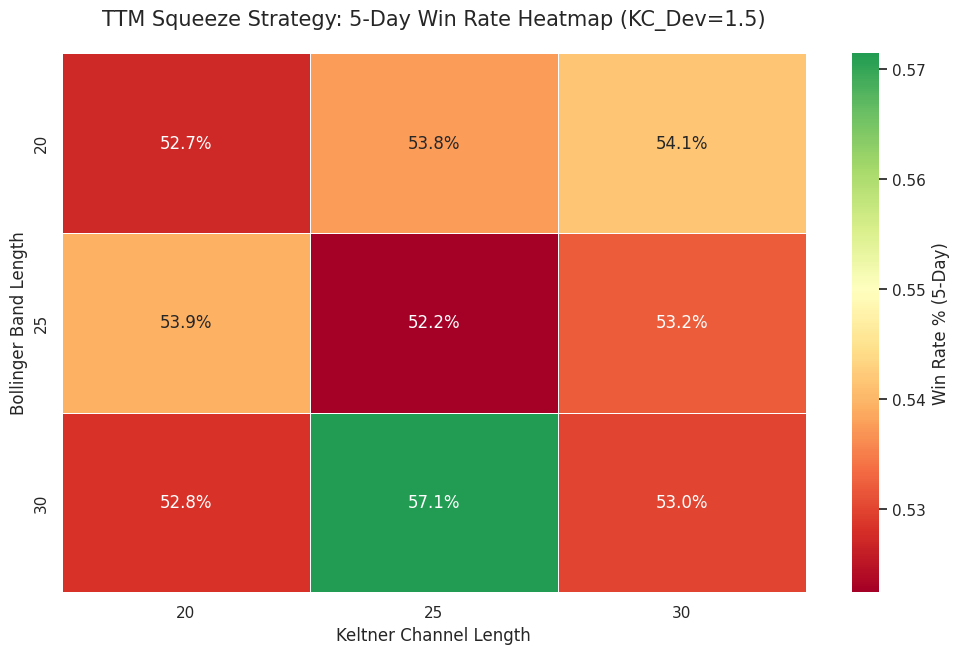

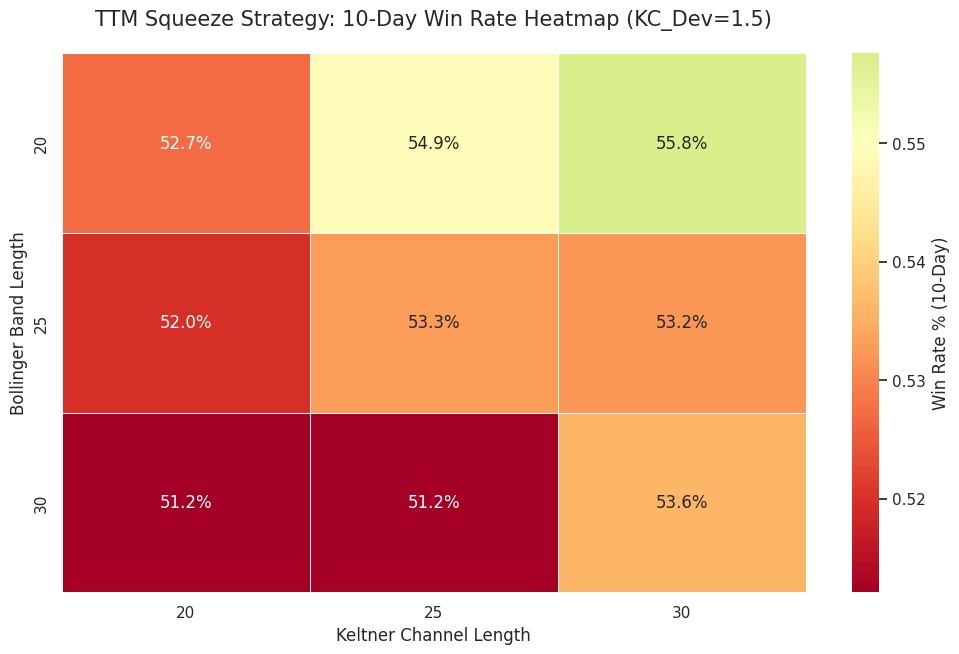

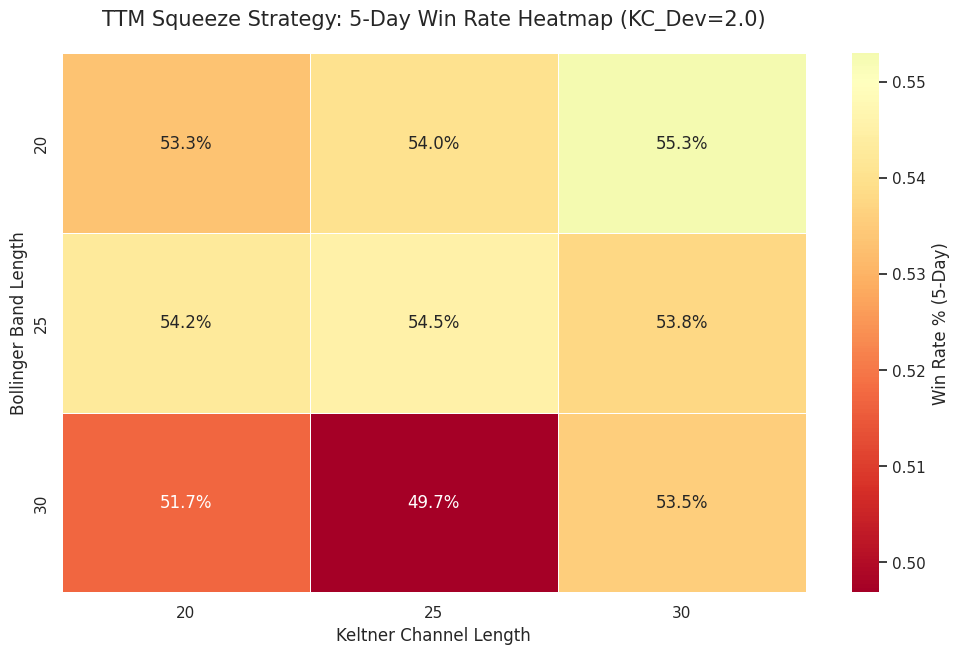

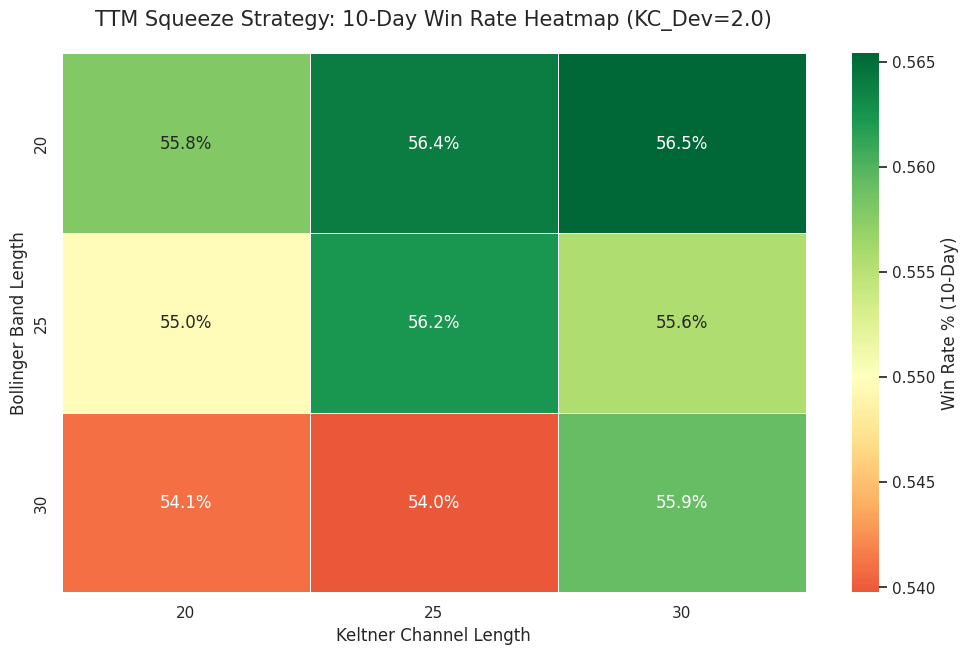

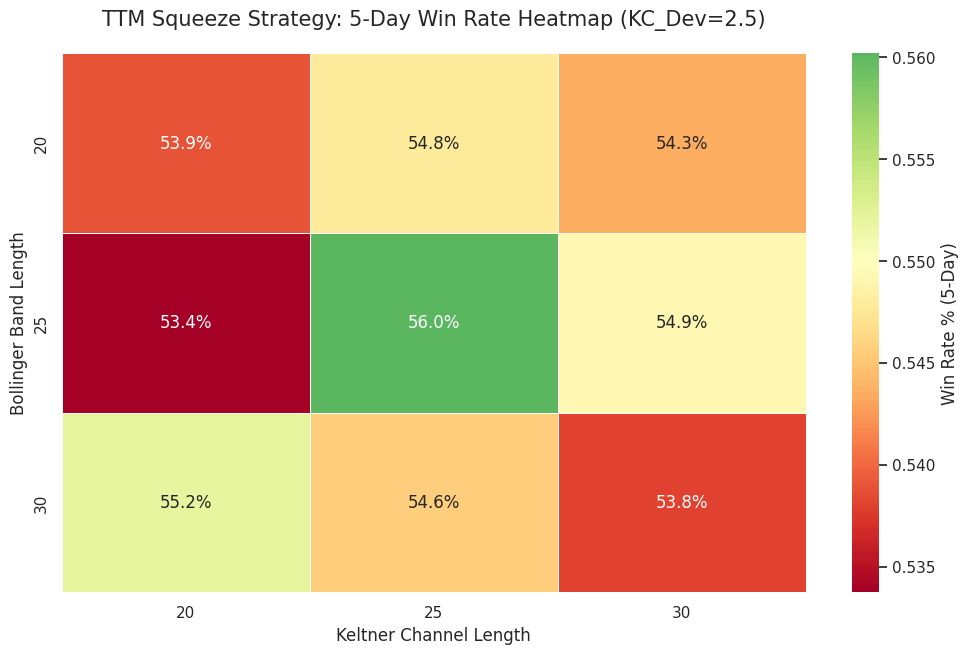

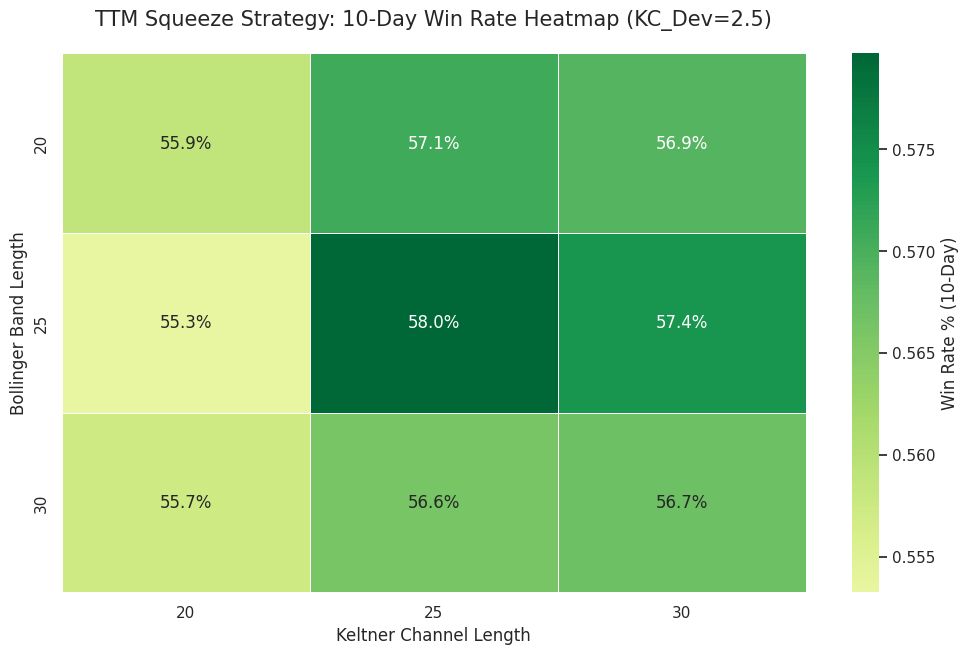

In [27]:
unique_kc_devs = summary_df['KC_Dev'].unique()

for kc_dev_val in sorted(unique_kc_devs):
    df_filtered = summary_df[summary_df['KC_Dev'] == kc_dev_val].copy()

    # 1. Pivot the data for 5-Day Win Rate
    heatmap_data_5d = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Win_Rate_5D")

    # 2. Set up the figure for 5-Day Win Rate Heatmap
    plt.figure(figsize=(12, 7))

    # 3. Create the heatmap for 5-Day Win Rate
    sns.heatmap(
        heatmap_data_5d,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",
        vmin=df_filtered["Win_Rate_5D"].min(),
        vmax=df_filtered["Win_Rate_5D"].max(),
        center=0.55,
        linewidths=.5,
        cbar_kws={'label': 'Win Rate % (5-Day)'}
    )

    # 4. Labels for 5-Day Win Rate Heatmap
    plt.title(f"TTM Squeeze Strategy: 5-Day Win Rate Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

    # --- Separator for 10-Day Win Rate Heatmap ---

    # 1. Pivot the data for 10-Day Win Rate
    heatmap_data_10d = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Win_Rate_10D")

    # 2. Set up the figure for 10-Day Win Rate Heatmap
    plt.figure(figsize=(12, 7))

    # 3. Create the heatmap for 10-Day Win Rate
    sns.heatmap(
        heatmap_data_10d,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",
        vmin=df_filtered["Win_Rate_10D"].min(),
        vmax=df_filtered["Win_Rate_10D"].max(),
        center=0.55,
        linewidths=.5,
        cbar_kws={'label': 'Win Rate % (10-Day)'}
    )

    # 4. Labels for 10-Day Win Rate Heatmap
    plt.title(f"TTM Squeeze Strategy: 10-Day Win Rate Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

## Average Return Heatmaps

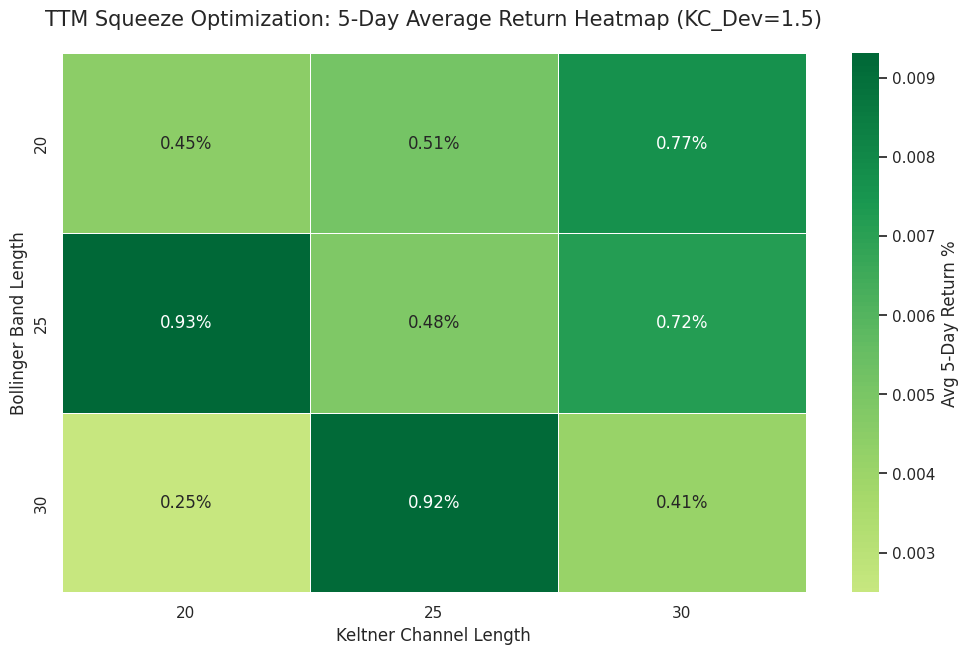

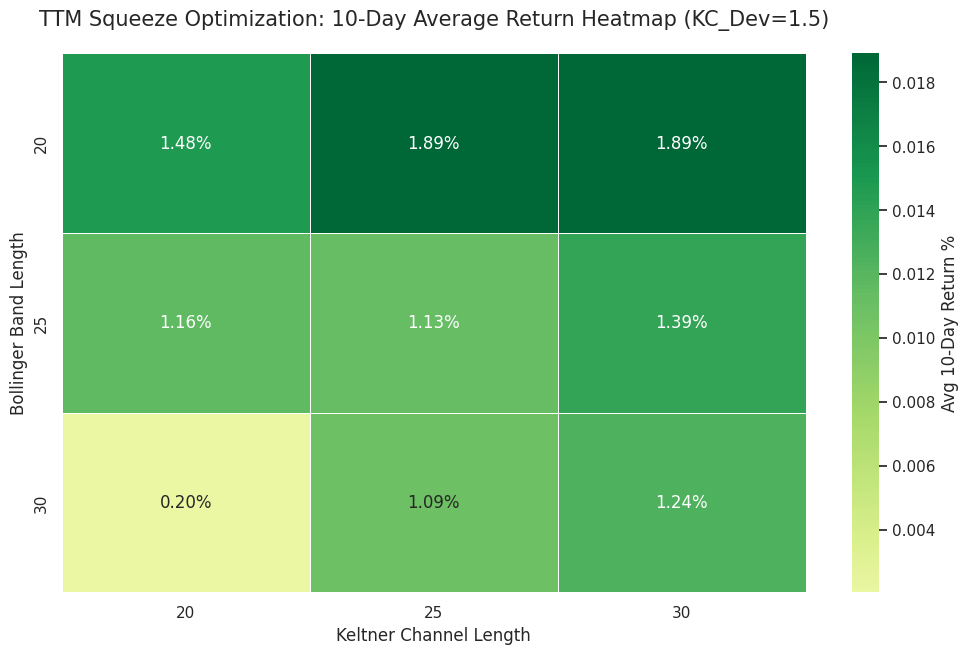

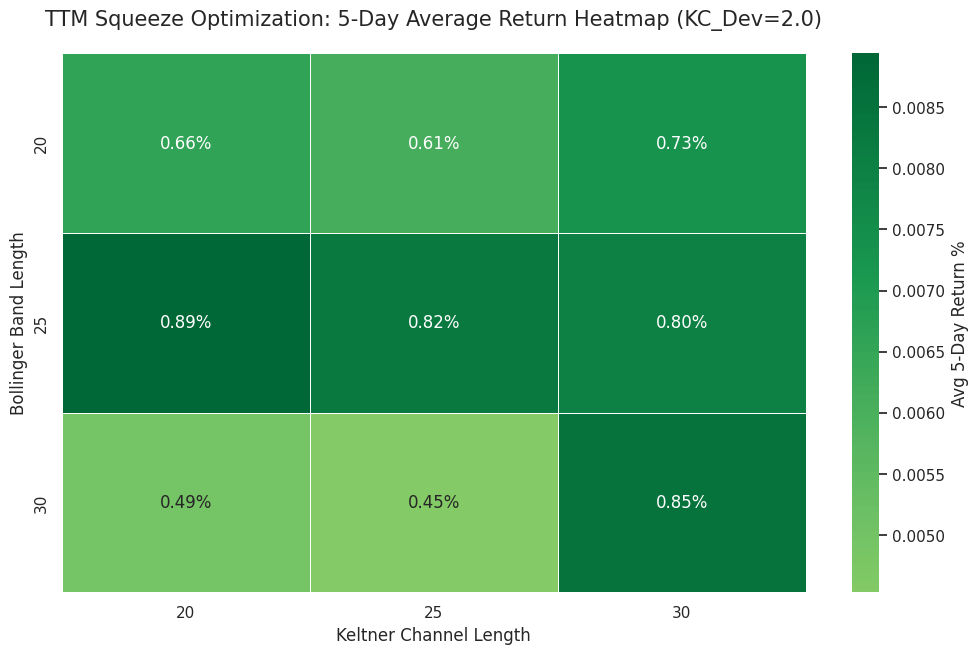

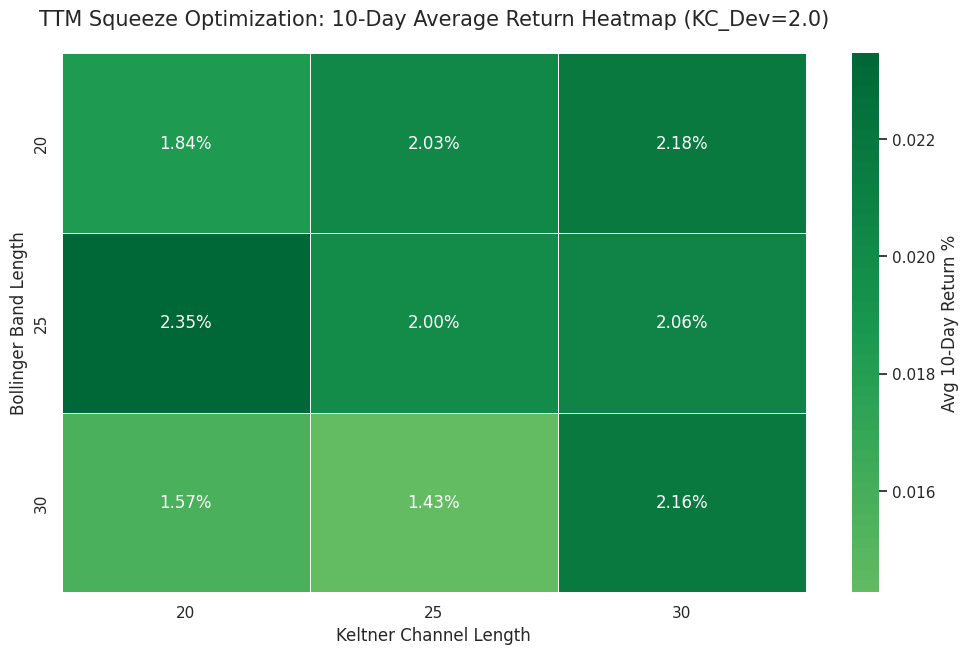

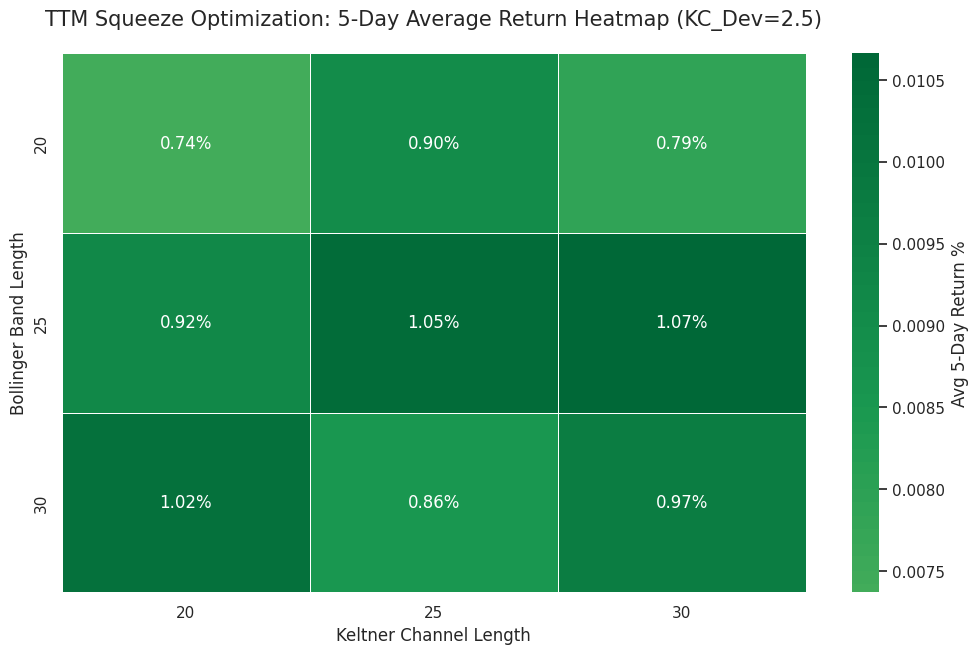

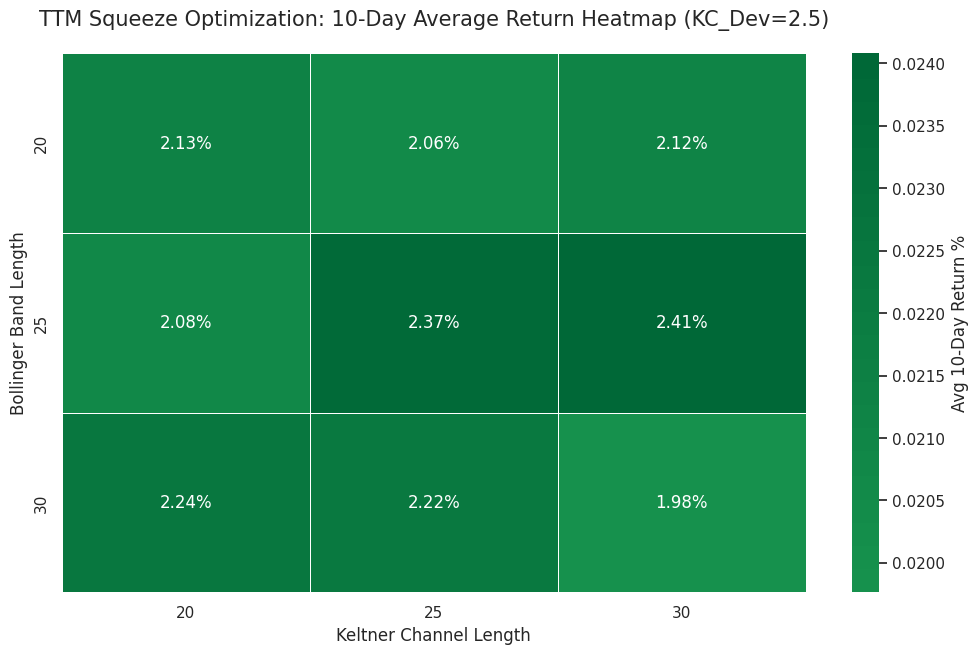

In [28]:
unique_kc_devs = summary_df['KC_Dev'].unique()

for kc_dev_val in sorted(unique_kc_devs):
    df_filtered = summary_df[summary_df['KC_Dev'] == kc_dev_val].copy()

    # 1. Pivot the data for Average 5-Day Return
    heatmap_data_5d_avg = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Avg_5D")

    # 2. Set up the figure for Average 5-Day Return Heatmap
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="white")

    # 3. Create the heatmap with optimized gradient parameters
    sns.heatmap(
        heatmap_data_5d_avg,
        annot=True,
        fmt=".2%",
        cmap="RdYlGn",
        vmin=df_filtered["Avg_5D"].min(),
        vmax=df_filtered["Avg_5D"].max(),
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Avg 5-Day Return %'}
    )

    # 4. Labels and Title
    plt.title(f"TTM Squeeze Optimization: 5-Day Average Return Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

    # --- Separator for Average 10-Day Return Heatmap ---

    # 1. Pivot the data for Average 10-Day Return
    heatmap_data_10d_avg = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Avg_10D")

    # 2. Set up the figure for Average 10-Day Return Heatmap
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="white")

    # 3. Create the heatmap with optimized gradient parameters
    sns.heatmap(
        heatmap_data_10d_avg,
        annot=True,
        fmt=".2%",
        cmap="RdYlGn",
        vmin=df_filtered["Avg_10D"].min(),
        vmax=df_filtered["Avg_10D"].max(),
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Avg 10-Day Return %'}
    )

    # 4. Labels and Title
    plt.title(f"TTM Squeeze Optimization: 10-Day Average Return Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

## 2022 TTM Squeeze Backtest

In [29]:
# --- 1. Configuration & Symbol Loading ---
# TTM Squeeze Configuration Parameters
BB_LENGTHS = [20, 25, 30]  # Bollinger Band lengths
KC_LENGTHS = [20, 25, 30]  # Keltner Channel lengths
KC_DEVS = [1.5, 2.0, 2.5]   # Keltner Channel deviation multiples
BB_DEVS = 2.0 # Standard Bollinger Band deviation

# Data window to capture all of 2022 with buffers for indicators and returns
START_DATE = "2021-11-01"
END_DATE = "2023-01-20"

try:
    df_csv = pd.read_csv(OptionVolume)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT", "AMD", "META"]

# --- 2. TTM Squeeze Function ---
def calculate_ttm_squeeze(df, bb_len, bb_dev, kc_len, kc_dev):
    # Bollinger Bands
    df['SMA'] = df['Close'].rolling(window=bb_len).mean()
    df['StdDev'] = df['Close'].rolling(window=bb_len).std()
    df['BB_Upper'] = df['SMA'] + (df['StdDev'] * bb_dev)
    df['BB_Lower'] = df['SMA'] - (df['StdDev'] * bb_dev)

    # Keltner Channels
    df['TR'] = np.maximum(df['High'] - df['Low'],
                          np.maximum(abs(df['High'] - df['Close'].shift()),
                                     abs(df['Low'] - df['Close'].shift())))
    df['ATR'] = df['TR'].rolling(window=kc_len).mean()
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['KC_Middle'] = df['Typical_Price'].rolling(window=kc_len).mean()
    df['KC_Upper'] = df['KC_Middle'] + (df['ATR'] * kc_dev)
    df['KC_Lower'] = df['KC_Middle'] - (df['ATR'] * kc_dev)

    # TTM Squeeze Condition: Squeeze is "on" when BB are inside KC
    df['in_squeeze'] = (df['BB_Lower'] > df['KC_Lower']) & \
                       (df['BB_Upper'] < df['KC_Upper'])

    # Momentum Oscillator (similar to ThinkorSwim's TTM Squeeze histogram)
    df['Momentum_Value1'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['Momentum_Value2'] = df['Momentum_Value1'].rolling(window=20).mean()
    df['Momentum_Raw'] = df['Momentum_Value1'] - df['Momentum_Value2']
    df['Momentum_Smoothed'] = df['Momentum_Raw'].rolling(window=4).mean()
    df['is_positive_momentum'] = df['Momentum_Smoothed'] > 0

    return df

# --- 3. Data Fetching & Vectorized Math ---
print(f"Fetching data from {START_DATE} to {END_DATE}...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Vectorized Future Returns (Shifted backwards)
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep for 2022 ---
all_results = []

print("Running 2022 Analysis (Bullish Momentum Only)...")
for bb_len in BB_LENGTHS:
    for kc_len in KC_LENGTHS:
        for kc_dev in KC_DEVS:
            param_trades = []

            print(f"Processing BB_Len={bb_len}, KC_Len={kc_len}, KC_Dev={kc_dev}")

            for symbol, df_orig in data_cache.items():
                df = df_orig.copy()
                df = calculate_ttm_squeeze(df, bb_len=bb_len, bb_dev=BB_DEVS, kc_len=kc_len, kc_dev=kc_dev)

                # --- CRITICAL FILTER: Only include signals that triggered in 2022 ---
                mask_2022 = (df.index >= "2022-01-01") & (df.index <= "2022-12-31")
                # Squeeze fires when it was in squeeze, and now it's not.
                # AND we add the positive momentum condition for a bullish squeeze.
                condition = (df['in_squeeze'].shift(1) == True) & \
                            (df['in_squeeze'] == False) & \
                            (df['is_positive_momentum'] == True)
                trades = df[mask_2022 & condition].dropna(subset=['in_squeeze', 'is_positive_momentum', 'Ret_10D']).copy()

                if not trades.empty:
                    trades['BB_Len'] = bb_len
                    trades['KC_Len'] = kc_len
                    trades['KC_Dev'] = kc_dev
                    trades['Symbol'] = symbol
                    param_trades.append(trades)

            if param_trades:
                combined = pd.concat(param_trades)
                all_results.append({
                    "BB_Len": bb_len,
                    "KC_Len": kc_len,
                    "KC_Dev": kc_dev,
                    "Avg_3D": combined['Ret_3D'].mean(),
                    "Avg_5D": combined['Ret_5D'].mean(),
                    "Avg_10D": combined['Ret_10D'].mean(),
                    "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                    "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                    "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                    "Trade_Count": len(combined)
                })

# --- 5. Summary Table ---
if all_results:
    summary_df_2022 = pd.DataFrame(all_results)
    summary_df_2022 = summary_df_2022.sort_values(by="Avg_5D", ascending=False)

    print("\n--- 2022 TTM SQUEEZE BACKTEST SUMMARY (BULLISH MOMENTUM ONLY) ---")
    display(summary_df_2022)
    summary_df_2022.to_csv("ttm_squeeze_results_2022_bullish_momentum.csv", index=False)
else:
    print("No bullish momentum trades triggered in 2022 with current parameters.")

Loaded 100 symbols from OptionVolume
Fetching data from 2021-11-01 to 2023-01-20...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IBIT']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CRWV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NBIS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
E

Running 2022 Analysis (Bullish Momentum Only)...
Processing BB_Len=20, KC_Len=20, KC_Dev=1.5
Processing BB_Len=20, KC_Len=20, KC_Dev=2.0
Processing BB_Len=20, KC_Len=20, KC_Dev=2.5
Processing BB_Len=20, KC_Len=25, KC_Dev=1.5
Processing BB_Len=20, KC_Len=25, KC_Dev=2.0
Processing BB_Len=20, KC_Len=25, KC_Dev=2.5
Processing BB_Len=20, KC_Len=30, KC_Dev=1.5
Processing BB_Len=20, KC_Len=30, KC_Dev=2.0
Processing BB_Len=20, KC_Len=30, KC_Dev=2.5
Processing BB_Len=25, KC_Len=20, KC_Dev=1.5
Processing BB_Len=25, KC_Len=20, KC_Dev=2.0
Processing BB_Len=25, KC_Len=20, KC_Dev=2.5
Processing BB_Len=25, KC_Len=25, KC_Dev=1.5
Processing BB_Len=25, KC_Len=25, KC_Dev=2.0
Processing BB_Len=25, KC_Len=25, KC_Dev=2.5
Processing BB_Len=25, KC_Len=30, KC_Dev=1.5
Processing BB_Len=25, KC_Len=30, KC_Dev=2.0
Processing BB_Len=25, KC_Len=30, KC_Dev=2.5
Processing BB_Len=30, KC_Len=20, KC_Dev=1.5
Processing BB_Len=30, KC_Len=20, KC_Dev=2.0
Processing BB_Len=30, KC_Len=20, KC_Dev=2.5
Processing BB_Len=30, KC_Le

,BB_Len,KC_Len,KC_Dev,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
21,30,25,1.5,0.003580,0.013579,0.007505,0.595745,0.617021,0.489362,47
15,25,30,1.5,0.002941,0.007982,0.014067,0.557692,0.557692,0.615385,52
17,25,30,2.5,0.001838,0.007934,0.002815,0.468182,0.513636,0.513636,220
20,30,20,2.5,-0.003329,0.005756,0.000029,0.456522,0.530435,0.504348,230
25,30,30,2.0,0.001211,0.005312,0.005559,0.497175,0.508475,0.525424,177
23,30,25,2.5,0.003229,0.004747,0.002620,0.500000,0.508696,0.500000,230
9,25,20,1.5,0.003363,0.004578,0.004115,0.545455,0.454545,0.480519,77
26,30,30,2.5,0.000770,0.004507,-0.000669,0.446903,0.482301,0.491150,226
19,30,20,2.0,0.000899,0.002715,0.012905,0.428571,0.460317,0.531746,126
24,30,30,1.5,-0.003950,0.001707,0.013434,0.490196,0.490196,0.509804,51


## Visualize 2022 TTM Squeeze Backtest Data

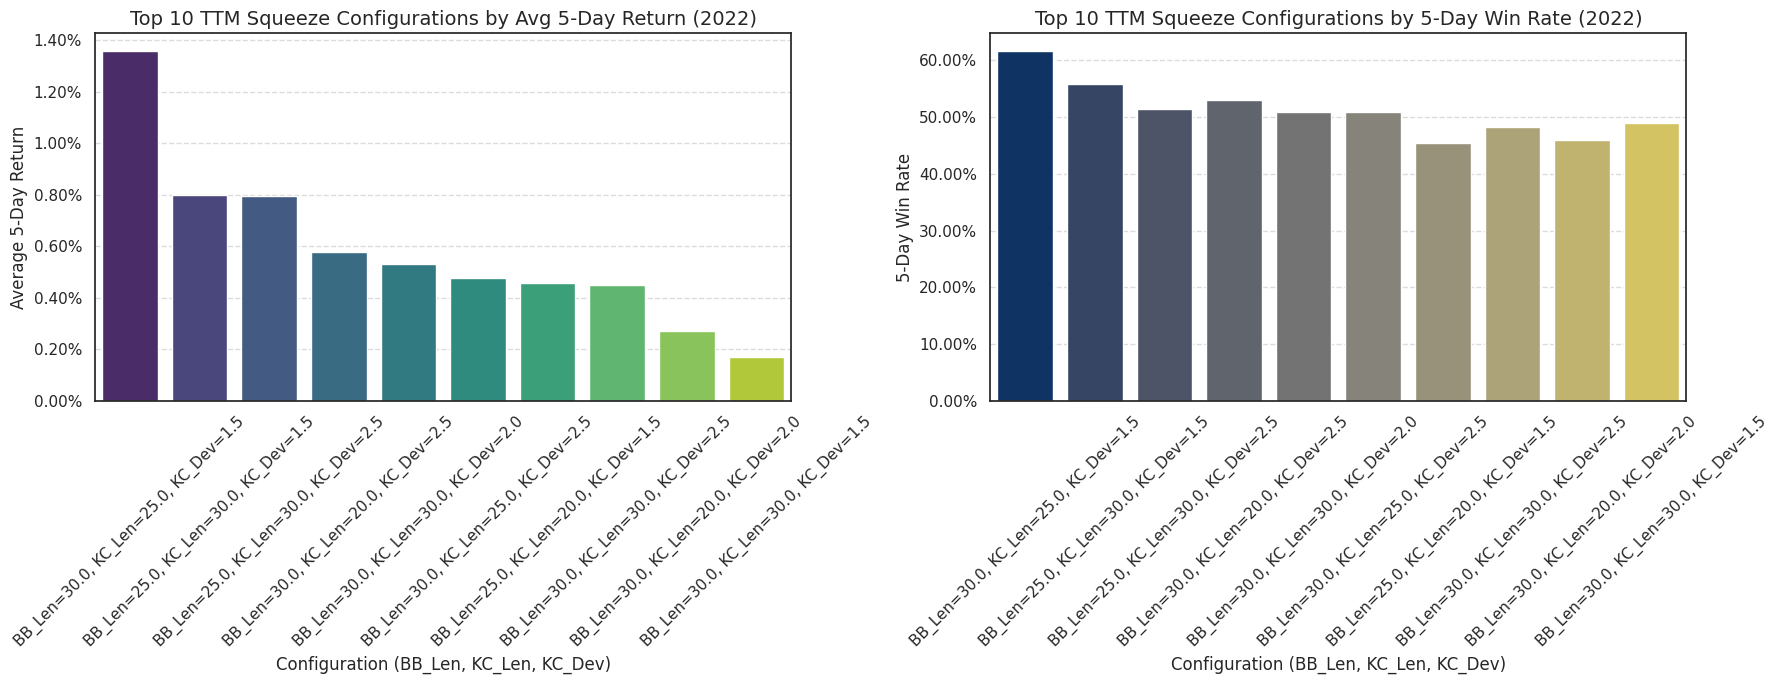


--- Top 10 TTM Squeeze Configurations (2022 Backtest) ---


,BB_Len,KC_Len,KC_Dev,Avg_5D,Win_Rate_5D,Trade_Count
21,30,25,1.5,0.013579,0.617021,47
15,25,30,1.5,0.007982,0.557692,52
17,25,30,2.5,0.007934,0.513636,220
20,30,20,2.5,0.005756,0.530435,230
25,30,30,2.0,0.005312,0.508475,177
23,30,25,2.5,0.004747,0.508696,230
9,25,20,1.5,0.004578,0.454545,77
26,30,30,2.5,0.004507,0.482301,226
19,30,20,2.0,0.002715,0.460317,126
24,30,30,1.5,0.001707,0.490196,51


In [30]:
# Assuming summary_df_2022 contains the results from the 2022 TTM Squeeze Backtest

if 'summary_df_2022' in locals() and not summary_df_2022.empty:

    # Sort for better visualization if not already sorted
    df_plot = summary_df_2022.sort_values(by='Avg_5D', ascending=False).head(10)

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Average 5-Day Return
    sns.barplot(
        x=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        y='Avg_5D',
        data=df_plot,
        ax=axes[0],
        palette='viridis',
        hue=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        legend=False
    )
    axes[0].set_title('Top 10 TTM Squeeze Configurations by Avg 5-Day Return (2022)', fontsize=14)
    axes[0].set_ylabel('Average 5-Day Return', fontsize=12)
    axes[0].set_xlabel('Configuration (BB_Len, KC_Len, KC_Dev)', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot 2: 5-Day Win Rate
    sns.barplot(
        x=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        y='Win_Rate_5D',
        data=df_plot,
        ax=axes[1],
        palette='cividis',
        hue=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        legend=False
    )
    axes[1].set_title('Top 10 TTM Squeeze Configurations by 5-Day Win Rate (2022)', fontsize=14)
    axes[1].set_ylabel('5-Day Win Rate', fontsize=12)
    axes[1].set_xlabel('Configuration (BB_Len, KC_Len, KC_Dev)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Print the top configurations in a table format
    print("\n--- Top 10 TTM Squeeze Configurations (2022 Backtest) ---")
    display(df_plot[['BB_Len', 'KC_Len', 'KC_Dev', 'Avg_5D', 'Win_Rate_5D', 'Trade_Count']])

else:
    print("No 2022 backtest results found to visualize. Please run the previous cell.")